# Pandas tasks - Cars93_missing.csv

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Read the CSV file into a DataFrame

In [23]:
df = pd.read_csv(
    "Cars93_missing.csv",
    keep_default_na=False,
    na_values=["NA"],
)

print(df.shape)
print(df.head())

(93, 27)
  Manufacturer    Model     Type  Min.Price  Price  Max.Price  MPG.city  \
0        Acura  Integra    Small       12.9   15.9       18.8      25.0   
1          NaN   Legend  Midsize       29.2   33.9       38.7      18.0   
2         Audi       90  Compact       25.9   29.1       32.3      20.0   
3         Audi      100  Midsize        NaN   37.7       44.6      19.0   
4          BMW     535i  Midsize        NaN   30.0        NaN      22.0   

   MPG.highway             AirBags DriveTrain  ... Passengers  Length  \
0         31.0                None      Front  ...        5.0   177.0   
1         25.0  Driver & Passenger      Front  ...        5.0   195.0   
2         26.0         Driver only      Front  ...        5.0   180.0   
3         26.0  Driver & Passenger        NaN  ...        6.0   193.0   
4         30.0                 NaN       Rear  ...        4.0   186.0   

   Wheelbase  Width  Turn.circle Rear.seat.room  Luggage.room  Weight  \
0      102.0   68.0         

## 2. Use a Series as the index

In [24]:
print(type(df["Model"]))

df = df.set_index("Model")
print(df.head())

<class 'pandas.Series'>
        Manufacturer     Type  Min.Price  Price  Max.Price  MPG.city  \
Model                                                                  
Integra        Acura    Small       12.9   15.9       18.8      25.0   
Legend           NaN  Midsize       29.2   33.9       38.7      18.0   
90              Audi  Compact       25.9   29.1       32.3      20.0   
100             Audi  Midsize        NaN   37.7       44.6      19.0   
535i             BMW  Midsize        NaN   30.0        NaN      22.0   

         MPG.highway             AirBags DriveTrain Cylinders  ...  \
Model                                                          ...   
Integra         31.0                None      Front         4  ...   
Legend          25.0  Driver & Passenger      Front         6  ...   
90              26.0         Driver only      Front         6  ...   
100             26.0  Driver & Passenger        NaN         6  ...   
535i            30.0                 NaN       Rear

## 3. Change data with a condition

In [25]:
condition = df["Origin"] == "non-USA"
print("Rows to change:", condition.sum())

df.loc[condition, "Origin"] = "Foreign"

print(df["Origin"].value_counts())

Rows to change: 42
Origin
USA        46
Foreign    42
Name: count, dtype: int64


## 4. Column names and number of missing values

In [26]:
print(df.columns.tolist())

print(df.isnull().sum())

print("Total missing:", df.isnull().sum().sum())

['Manufacturer', 'Type', 'Min.Price', 'Price', 'Max.Price', 'MPG.city', 'MPG.highway', 'AirBags', 'DriveTrain', 'Cylinders', 'EngineSize', 'Horsepower', 'RPM', 'Rev.per.mile', 'Man.trans.avail', 'Fuel.tank.capacity', 'Passengers', 'Length', 'Wheelbase', 'Width', 'Turn.circle', 'Rear.seat.room', 'Luggage.room', 'Weight', 'Origin', 'Make']
Manufacturer           4
Type                   3
Min.Price              7
Price                  2
Max.Price              5
MPG.city               9
MPG.highway            2
AirBags                6
DriveTrain             7
Cylinders              5
EngineSize             2
Horsepower             7
RPM                    3
Rev.per.mile           6
Man.trans.avail        5
Fuel.tank.capacity     8
Passengers             2
Length                 4
Wheelbase              1
Width                  6
Turn.circle            5
Rear.seat.room         4
Luggage.room          19
Weight                 7
Origin                 5
Make                   3
dtype: int

## 5. Swap two columns with a function, then sort columns by name

In [27]:
def swap_columns(data, col1, col2):
    cols = data.columns.tolist()
    i, j = cols.index(col1), cols.index(col2)
    cols[i], cols[j] = cols[j], cols[i]
    return data[cols]

print("Before:", df.columns.tolist()[:5])
df = swap_columns(df, "Min.Price", "Max.Price")
print("After: ", df.columns.tolist()[:5])

Before: ['Manufacturer', 'Type', 'Min.Price', 'Price', 'Max.Price']
After:  ['Manufacturer', 'Type', 'Max.Price', 'Price', 'Min.Price']


In [28]:
df = df.sort_index(axis=1)
print(df.columns.tolist())

['AirBags', 'Cylinders', 'DriveTrain', 'EngineSize', 'Fuel.tank.capacity', 'Horsepower', 'Length', 'Luggage.room', 'MPG.city', 'MPG.highway', 'Make', 'Man.trans.avail', 'Manufacturer', 'Max.Price', 'Min.Price', 'Origin', 'Passengers', 'Price', 'RPM', 'Rear.seat.room', 'Rev.per.mile', 'Turn.circle', 'Type', 'Weight', 'Wheelbase', 'Width']


## 6. Delete the top 5% and bottom 5%

In [29]:
low = df["Price"].quantile(0.05)
high = df["Price"].quantile(0.95)
print("Limits:", round(low, 2), "and", round(high, 2))

print("Rows before:", len(df))
keep = df["Price"].between(low, high) | df["Price"].isna()
df = df[keep]
print("Rows after: ", len(df))

Limits: 8.5 and 36.9
Rows before: 93
Rows after:  83


## 7. Replace missing values with the average

In [30]:
mean_price = df["Price"].mean()
print("Mean price:", round(mean_price, 2))
print("Missing before:", df["Price"].isnull().sum())

df["Price"] = df["Price"].fillna(mean_price)
print("Missing after: ", df["Price"].isnull().sum())

Mean price: 18.75
Missing before: 2
Missing after:  0


In [31]:
num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df[num_cols].apply(lambda col: col.fillna(col.mean()))

print("Missing in number columns:", df[num_cols].isnull().sum().sum())

Missing in number columns: 0


## 8. Two DataFrames from two dicts, merge them, add a new column

In [32]:
dict1 = {
    "Manufacturer": ["Toyota", "Honda", "Ford", "BMW", "Audi"],
    "Country": ["Japan", "Japan", "USA", "Germany", "Germany"],
}
dict2 = {
    "Manufacturer": ["Toyota", "Honda", "Ford", "BMW", "Volvo"],
    "Founded": [1937, 1948, 1903, 1916, 1927],
}

df1 = pd.DataFrame(dict1)
df2 = pd.DataFrame(dict2)
print(df1)
print(df2)

  Manufacturer  Country
0       Toyota    Japan
1        Honda    Japan
2         Ford      USA
3          BMW  Germany
4         Audi  Germany
  Manufacturer  Founded
0       Toyota     1937
1        Honda     1948
2         Ford     1903
3          BMW     1916
4        Volvo     1927


In [33]:
# Merge
merged = pd.merge(df1, df2, on="Manufacturer")
print(merged)

  Manufacturer  Country  Founded
0       Toyota    Japan     1937
1        Honda    Japan     1948
2         Ford      USA     1903
3          BMW  Germany     1916


In [34]:
df1["Founded"] = df2["Founded"]
print(df1)

  Manufacturer  Country  Founded
0       Toyota    Japan     1937
1        Honda    Japan     1948
2         Ford      USA     1903
3          BMW  Germany     1916
4         Audi  Germany     1927


## 9. Histogram

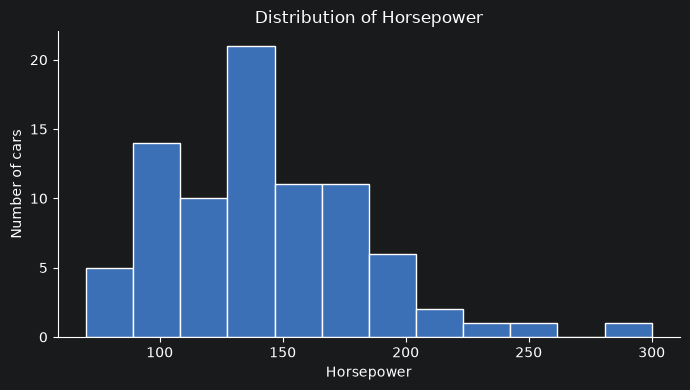

In [35]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["Horsepower"], bins=12, color="#3b6fb6", edgecolor="white")
ax.set_title("Distribution of Horsepower")
ax.set_xlabel("Horsepower")
ax.set_ylabel("Number of cars")
ax.yaxis.get_major_locator().set_params(integer=True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 10. Correlation matrix

In [36]:
# number columns only
corr = df.corr(numeric_only=True)
print(corr.round(2))

                    EngineSize  Fuel.tank.capacity  Horsepower  Length  \
EngineSize                1.00                0.73        0.59    0.81   
Fuel.tank.capacity        0.73                1.00        0.59    0.59   
Horsepower                0.59                0.59        1.00    0.47   
Length                    0.81                0.59        0.47    1.00   
Luggage.room              0.65                0.49        0.31    0.71   
MPG.city                 -0.67               -0.76       -0.53   -0.57   
MPG.highway              -0.58               -0.75       -0.52   -0.43   
Max.Price                 0.46                0.47        0.68    0.42   
Min.Price                 0.54                0.47        0.67    0.52   
Passengers                0.51                0.52       -0.01    0.42   
Price                     0.54                0.53        0.74    0.50   
RPM                      -0.67               -0.43       -0.01   -0.56   
Rear.seat.room            0.49        

In [37]:
print(corr["Price"].drop("Price").sort_values(ascending=False).round(2))

Max.Price             0.93
Min.Price             0.93
Horsepower            0.74
Weight                0.61
EngineSize            0.54
Fuel.tank.capacity    0.53
Length                0.50
Wheelbase             0.50
Turn.circle           0.42
Width                 0.38
Luggage.room          0.36
Rear.seat.room        0.31
Passengers            0.07
RPM                  -0.13
Rev.per.mile         -0.39
MPG.highway          -0.53
MPG.city             -0.60
Name: Price, dtype: float64


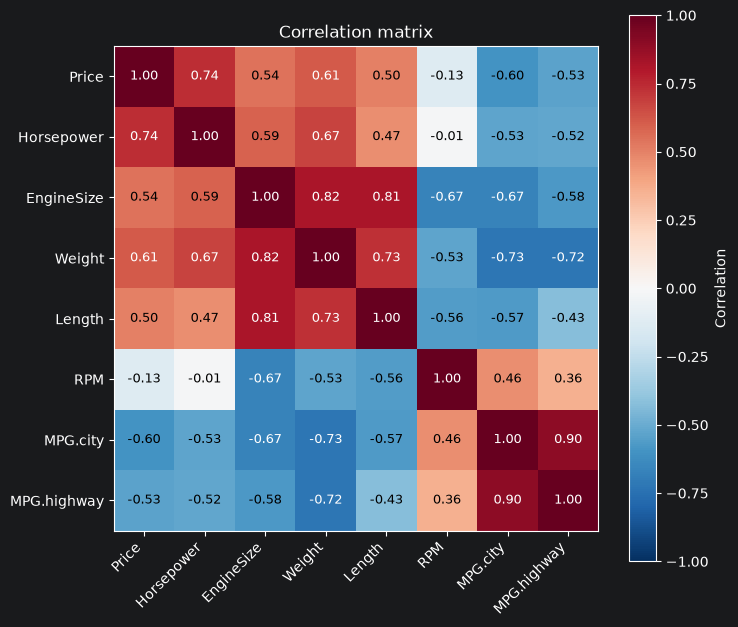

In [38]:
cols = ["Price", "Horsepower", "EngineSize", "Weight", "Length", "RPM", "MPG.city", "MPG.highway"]
c = df[cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(c, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(cols)), cols, rotation=45, ha="right")
ax.set_yticks(range(len(cols)), cols)

for i in range(len(cols)):
    for j in range(len(cols)):
        v = c.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.6 else "black", fontsize=9)

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.show()